In [ ]:
""" Comentário pós aula

Estudamos ferramentas de busca de hiperparâmetros, como o GridSearch

"""Calcular a métrica várias vezes e verificar qual modelo tem o melhor scoring médio"""

"""O pre-processamento fica igual, mas com uma nova etapa de otimização de hiperparâmetros"""

""" Passos realizados (antes do Grid Search)

1) Separar features X e target y 
2) Separar dados de treino e de teste
3) SimpleImputer: Fit do X_train numérico, transform no X_train e X_test numéricos
4) StandardScaler: Fit do X_train numérico, transform no X_train e X_test numéricos
5) Random Forest: Fit dos dados de X_train e y_train
6) Cria y_pred_test = rf.predict(X_test)
7) Cria ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
8) Print do classification_report(y_test, y_pred_test)
"""

""" K Fold dobra os dados em K vezes, e divide essas dobras em treino e teste (cross validation)
O GridSearchCV faz a otimização de Hiperparâmetros - ele escolhe quais parâmetros serão testados
E depois escolhe qual modelo entrega a melhor combinação de parâmetros baseada na melhor média das avaliações.
"""

""" Criar um splitter = usar o Kfold para dobrar os dados 10 vezes (n_splits = 10)
metrica = "accuracy" = métrica que será usada para avaliar o estimador

Depois, define um dicionário do grid de parâmetros que será usado no GridSearchCV
- estimador = rf (Random Forest - método que será usado),
- param_grid - dicionário com os critérios criados para teste
- scoring = metrica (accuracy) - o que ele usará como critério
- cv (cross validation) = splitter - mostra que eu vou utilizar o KFold
- verbose = 10 - vai mostrar na tela o que vai acontecer


""" Uma alternativa ao GridSearchCV é o RandomSearch
from sklearn.model_selection import RandomizedSearchCV

O processo é fazer o grid_rf = RandomizedSearchCV
E mudar o param_grid para param_distributions
"""


# Aula 09 - Hiperparâmetros e Otimização

Até o momento, estudamos uma série de situações em que, de maneira ilustrativa, observamos grande variação nos resultados, seguidas da alteração dos hiperparâmetros de diferentes modelos. Em geral, estávamos escolhendo valores arbitrariamente; mas como tentar determinar, sempre, os melhores hiperparâmetros, ou, minimamente, boas escolhas de valores para eles?

___

### Grid Search

O [Gridsearch](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) é uma estrutura que o sklearn proporciona para que seja feita **a busca exaustiva de hiperparâmetros de um estimador**.

Na prática, o que o gridsearch faz é **treinar diversos modelos com diferentes combinações de hiperparâmetros**, de modo a manter o melhor deles como o modelo final, tudo automaticamente! 

Tudo o que precisamos fazer é indicar quais os hiperparâmetros que queremos procurar, definindo a **grade de busca**!

<img src="https://www.yourdatateacher.com/wp-content/uploads/2021/03/image-6.png" width=500>

Desta forma, tentamos automatizar o processo de escolha dos valores ótimo de hiperparâmetros para os diferentes estimadores nos quais estivermos interessados. Com o GridSearch, definimos um universo de valores possíveis a partir dos quais combinações de hiperparâmetros são testadas, e obtemos aquela para a qual o algoritmo performa melhor no conjunto de validação!

O Gridsearch avalia o melhor modelo segundo a métrica que definimos em `scoring`. [Clique aqui](https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter) para ver as métricas disponíveis por padrão.

Mas o GS vai além: ele não calcula a métrica uma única vez, mas sim **várias vezes**, conforme especificado pelo parâmetro `cv`. No fim, o melhor modelo é o que tem o melhor scoring **médio** entre as vezes que é calculado.

(O "cv" quer dizer **Cross Validation**!)

<img src="https://ethen8181.github.io/machine-learning/model_selection/img/kfolds.png" width=600> 

**Dica de leitura complementar:** [documentação do sklearn sobre ajuste fino de hiperparâmetros](https://scikit-learn.org/stable/modules/grid_search.html#grid-search).


In [ ]:
"""Calcular a métrica várias vezes e verificar qual modelo tem o melhor scoring médio"""

___
### GridSearch na prática!

Para avaliar um caso de uso do GridSearch, vamos retornar à base de dados de crédito e ao modelo que vimos na aula passada, a **RandomForest**.

Trabalhando com o mesmo pré-processamento que fizemos até o momento, vamos replicá-lo e acrescentar a etapa de avaliação de otimização de hiperparâmetros.

In [ ]:
"""O pre-processamento fica igual, mas com uma nova etapa de otimização de hiperparâmetros"""

Primeiramente, vamos fazer a leitura da base de dados.

In [9]:
import pandas as pd
import numpy as np
df = pd.read_csv("datasets/german_credit_data.csv", index_col = 0)

Agora, vamos seguir com a divisão dos dados em treinamento e teste, e o pré-processamento que temos feito nas últimas aulas.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

In [13]:
# Separação entre features e target
X = df.drop(columns = "Risk")
y = df["Risk"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42, stratify = y)

In [15]:
# O SimpleImputer segue a mesma lógica de outros "transformers" que estudamos, como os de normalização/padronização
sim_imp = SimpleImputer(strategy = "mean").fit(X_train.select_dtypes(include = np.number))
X_train = sim_imp.transform(X_train.select_dtypes(include = np.number))
X_test = sim_imp.transform(X_test.select_dtypes(include = np.number))

# Scaling dos dados (após tratar os valores nulos)
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

Avaliação do modelo:
              precision    recall  f1-score   support

         bad       0.42      0.25      0.32        75
        good       0.73      0.85      0.78       175

    accuracy                           0.67       250
   macro avg       0.57      0.55      0.55       250
weighted avg       0.64      0.67      0.64       250



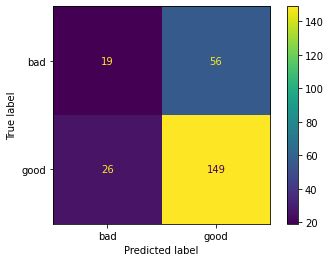

In [19]:
rf = RandomForestClassifier(random_state = 42)
rf.fit(X_train, y_train)
print("Avaliação do modelo:")
y_pred_test = rf.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
print(classification_report(y_test, y_pred_test))

In [ ]:
""" Passos realizados (antes do Grid Search)

1) Separar features X e target y 
2) Separar dados de treino e de teste
3) SimpleImputer: Fit do X_train numérico, transform no X_train e X_test numéricos
4) StandardScaler: Fit do X_train numérico, transform no X_train e X_test numéricos
5) Random Forest: Fit dos dados de X_train e y_train
6) Cria y_pred_test = rf.predict(X_test)
7) Cria ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
8) Print do classification_report(y_test, y_pred_test)
"""

Vamos importar o [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

In [24]:
from sklearn.model_selection import GridSearchCV, KFold #import

In [ ]:
""" K Fold dobra os dados em K vezes, e divide essas dobras em treino e teste (cross validation)
O GridSearchCV faz a otimização de Hiperparâmetros - ele escolhe quais parâmetros serão testados
E depois escolhe qual modelo entrega a melhor combinação de parâmetros baseada na melhor média das avaliações.
"""

In [20]:
rf.get_params() #pegar os parâmetros da Random Forest

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [22]:
from sklearn.model_selection import KFold

In [29]:
# Ajuste de hiperparâmetros da Random Forest com Grid Search

# Definição da estrutura de validação cruzada
splitter = KFold(n_splits = 10, shuffle = True, random_state = 42)
metrica = "accuracy" # definição da métrica de avaliação do estimador

# Procura dos melhores hiperparâmetros - gridsearch

# Definimos, em um dicionário, os valores do nosso "grid"
param_grid = {"max_depth": range(2,8),
             "criterion": ["gini", "entropy"]}

# definição do estimador
rf = RandomForestClassifier()

# grid search
grid_rf = GridSearchCV(estimator = rf,
                           param_grid = param_grid,
                           scoring = metrica,
                           cv = splitter, verbose = 10)

In [ ]:
""" Criar um splitter = usar o Kfold para dobrar os dados 10 vezes (n_splits = 10)
metrica = "accuracy" = métrica que será usada para avaliar o estimador

Depois, define um dicionário do grid de parâmetros que será usado no GridSearchCV
- estimador = rf (Random Forest - método que será usado),
- param_grid - dicionário com os critérios criados para teste
- scoring = metrica (accuracy) - o que ele usará como critério
- cv (cross validation) = splitter - mostra que eu vou utilizar o KFold
- verbose = 10 - vai mostrar na tela o que vai acontecer

In [30]:
grid_rf # executar o GridSearch

GridSearchCV(cv=KFold(n_splits=10, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(2, 8)},
             scoring='accuracy', verbose=10)

In [31]:
grid_rf.fit(X_train, y_train) #fitando os dados de teste com grid_rf

Fitting 10 folds for each of 12 candidates, totalling 120 fits
[CV 1/10; 1/12] START criterion=gini, max_depth=2...............................
[CV 1/10; 1/12] END criterion=gini, max_depth=2;, score=0.733 total time=   0.0s
[CV 2/10; 1/12] START criterion=gini, max_depth=2...............................
[CV 2/10; 1/12] END criterion=gini, max_depth=2;, score=0.720 total time=   0.0s
[CV 3/10; 1/12] START criterion=gini, max_depth=2...............................
[CV 3/10; 1/12] END criterion=gini, max_depth=2;, score=0.747 total time=   0.0s
[CV 4/10; 1/12] START criterion=gini, max_depth=2...............................
[CV 4/10; 1/12] END criterion=gini, max_depth=2;, score=0.667 total time=   0.0s
[CV 5/10; 1/12] START criterion=gini, max_depth=2...............................
[CV 5/10; 1/12] END criterion=gini, max_depth=2;, score=0.680 total time=   0.0s
[CV 6/10; 1/12] START criterion=gini, max_depth=2...............................
[CV 6/10; 1/12] END criterion=gini, max_depth=

[CV 1/10; 6/12] END criterion=gini, max_depth=7;, score=0.747 total time=   0.0s
[CV 2/10; 6/12] START criterion=gini, max_depth=7...............................
[CV 2/10; 6/12] END criterion=gini, max_depth=7;, score=0.720 total time=   0.0s
[CV 3/10; 6/12] START criterion=gini, max_depth=7...............................
[CV 3/10; 6/12] END criterion=gini, max_depth=7;, score=0.707 total time=   0.0s
[CV 4/10; 6/12] START criterion=gini, max_depth=7...............................
[CV 4/10; 6/12] END criterion=gini, max_depth=7;, score=0.653 total time=   0.0s
[CV 5/10; 6/12] START criterion=gini, max_depth=7...............................
[CV 5/10; 6/12] END criterion=gini, max_depth=7;, score=0.653 total time=   0.0s
[CV 6/10; 6/12] START criterion=gini, max_depth=7...............................
[CV 6/10; 6/12] END criterion=gini, max_depth=7;, score=0.707 total time=   0.0s
[CV 7/10; 6/12] START criterion=gini, max_depth=7...............................
[CV 7/10; 6/12] END criterio

[CV 1/10; 11/12] END criterion=entropy, max_depth=6;, score=0.733 total time=   0.0s
[CV 2/10; 11/12] START criterion=entropy, max_depth=6...........................
[CV 2/10; 11/12] END criterion=entropy, max_depth=6;, score=0.733 total time=   0.0s
[CV 3/10; 11/12] START criterion=entropy, max_depth=6...........................
[CV 3/10; 11/12] END criterion=entropy, max_depth=6;, score=0.747 total time=   0.0s
[CV 4/10; 11/12] START criterion=entropy, max_depth=6...........................
[CV 4/10; 11/12] END criterion=entropy, max_depth=6;, score=0.667 total time=   0.0s
[CV 5/10; 11/12] START criterion=entropy, max_depth=6...........................
[CV 5/10; 11/12] END criterion=entropy, max_depth=6;, score=0.680 total time=   0.0s
[CV 6/10; 11/12] START criterion=entropy, max_depth=6...........................
[CV 6/10; 11/12] END criterion=entropy, max_depth=6;, score=0.720 total time=   0.0s
[CV 7/10; 11/12] START criterion=entropy, max_depth=6...........................
[CV 

GridSearchCV(cv=KFold(n_splits=10, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(2, 8)},
             scoring='accuracy', verbose=10)

In [32]:
# Visualização dos melhores hiperparâmetros
grid_rf.best_params_

{'criterion': 'gini', 'max_depth': 5}

Vemos, assim, que os melhores resultados, no panorama que desenhamos, foram obtidos segundo o critério de Gini e com profundidade máxima de 5.

In [33]:
# visualização do melhor score para a métrica definida no processo
grid_rf.best_score_ #qual foi o resultado da accuracy

0.728

In [34]:
# Avaliação com o GridSearch

# predições no próprio conjunto de treinamento
y_pred_train = grid_rf.predict(X_train)
print(classification_report(y_train, y_pred_train))
print("\n")
# predições no conjunto de teste
y_pred_test = grid_rf.predict(X_test)
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

         bad       0.93      0.23      0.37       225
        good       0.75      0.99      0.85       525

    accuracy                           0.76       750
   macro avg       0.84      0.61      0.61       750
weighted avg       0.80      0.76      0.71       750



              precision    recall  f1-score   support

         bad       0.61      0.15      0.24        75
        good       0.72      0.96      0.83       175

    accuracy                           0.72       250
   macro avg       0.67      0.55      0.53       250
weighted avg       0.69      0.72      0.65       250



Vimos, assim, como funciona a implementação com o GridSearch!' Vale lembrar que podemos otimizar outros hiperparâmetros além dos que utilizamos anteriormente. Além disso, essa abordagem é replicável para qualquer tipo de estimador!

In [ ]:
""" Uma alternativa ao GridSearchCV é o RandomSearch
from sklearn.model_selection import RandomizedSearchCV

O processo é fazer o grid_rf = RandomizedSearchCV
E mudar o param_grid para param_distributions
"""